2026-05-21 10:45:29.021 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-05-21 10:45:29.023 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-05-21 10:45:29.023 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-05-21 10:45:29.024 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-05-21 10:45:29.025 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-05-21 10:45:29.027 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.


✅ Đã kết nối MySQL và đọc thành công 30,336 hàng từ bảng 'aqi_data'


2026-05-21 10:45:29.677 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-05-21 10:45:29.678 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-05-21 10:45:29.680 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-05-21 10:45:29.681 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-05-21 10:45:30.103 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-05-21 10:45:30.105 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-05-21 10:45:30.107 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.


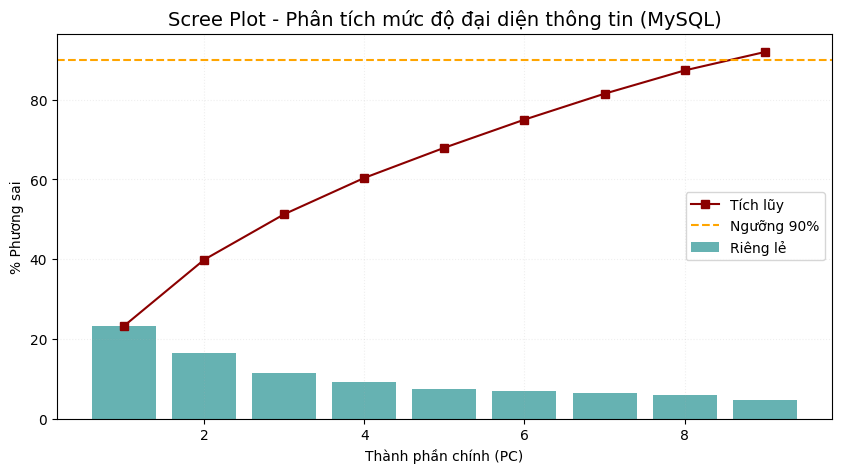

2026-05-21 10:45:31.626 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-05-21 10:45:31.628 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-05-21 10:45:31.629 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-05-21 10:45:31.630 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-05-21 10:45:32.523 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-05-21 10:45:32.524 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-05-21 10:45:32.525 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.


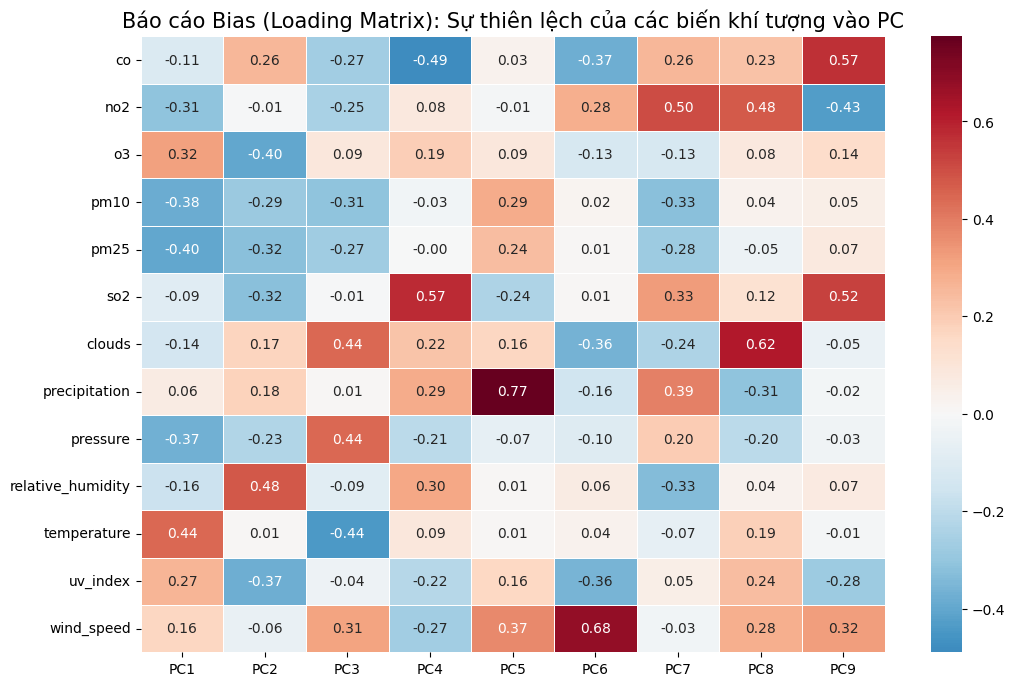

2026-05-21 10:45:38.081 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-05-21 10:45:38.082 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-05-21 10:45:38.085 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-05-21 10:45:38.086 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-05-21 10:45:40.574 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-05-21 10:45:40.575 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-05-21 10:45:40.576 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.


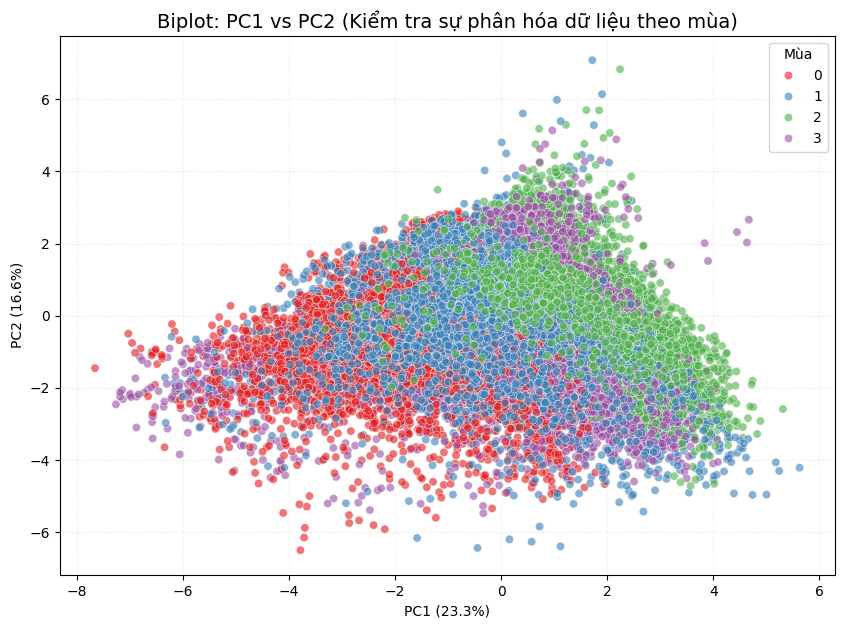

2026-05-21 10:45:42.306 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-05-21 10:45:42.309 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-05-21 10:45:42.311 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.



🔍 NHẬN XÉT VỀ TÍNH CÔNG BẰNG (BIAS):
1. Loading Matrix cho thấy PC1 bị ảnh hưởng mạnh bởi PM2.5 và Nhiệt độ.
2. Biplot cho thấy dữ liệu các mùa (Season) có sự tách biệt rõ rệt.
=> Kết luận: Dữ liệu nguồn vốn dĩ đã có sự khác biệt lớn theo mùa,
đây là nguyên nhân gốc rễ gây ra Bias trong mô hình Time Series sau này.


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sqlalchemy import create_engine
import warnings
import os
from dotenv import load_dotenv
from pathlib import Path
import streamlit as st  # Thêm thư viện Streamlit

warnings.filterwarnings('ignore', category=FutureWarning)

current_dir = Path(os.getcwd()).resolve()
if 'library_framework' in current_dir.parts:
    dotenv_path = current_dir.parent / '.env'
    charts_dir = current_dir.parent / 'charts'
else:
    dotenv_path = current_dir / '.env'
    charts_dir = current_dir / 'charts'

load_dotenv(dotenv_path=dotenv_path)
os.makedirs(charts_dir, exist_ok=True)

DB_USER = os.getenv("DB_USER")
DB_PASSWORD = os.getenv("DB_PASSWORD")
DB_HOST = os.getenv("DB_HOST")
DB_PORT = os.getenv("DB_PORT")
DB_NAME = os.getenv("DB_NAME")

engine = create_engine(f"mysql+pymysql://{DB_USER}:{DB_PASSWORD}@{DB_HOST}:{DB_PORT}/{DB_NAME}")

try:
    df = pd.read_sql('SELECT * FROM aqi_data', con=engine)
    print(f"✅ Đã kết nối MySQL và đọc thành công {len(df):,} hàng từ bảng 'aqi_data'")
except Exception as e:
    print(f"❌ Lỗi kết nối hoặc không tìm thấy bảng sạch: {e}")

df.columns = df.columns.str.strip().str.lower()

target_cols = ['co', 'no2', 'o3', 'pm10', 'pm25', 'so2', 'clouds',
               'precipitation', 'pressure', 'relative_humidity',
               'temperature', 'uv_index', 'wind_speed']

X = df[target_cols].apply(pd.to_numeric, errors='coerce')
X = X.fillna(X.median(numeric_only=True))

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
pca = PCA(n_components=9)
X_pca = pca.fit_transform(X_scaled)
exp_var = pca.explained_variance_ratio_ * 100

# --- CẤU HÌNH GIAO DIỆN HIỂN THỊ STREAMLIT ĐỒNG BỘ ---
st.title("📊 Báo Cáo Phân Tích Chuyên Sâu Khử Chiều Dữ Liệu PCA")
st.markdown("Hệ thống tự động đồng bộ kết quả trực tiếp từ cơ sở dữ liệu MySQL.")

# =================================================================
# Biểu đồ 1: Scree Plot
# =================================================================
fig1 = plt.figure(figsize=(10, 5))
plt.bar(range(1, 10), exp_var, alpha=0.6, color='teal', label='Riêng lẻ')
plt.plot(range(1, 10), np.cumsum(exp_var), marker='s', color='darkred', label='Tích lũy')
plt.axhline(y=90, color='orange', linestyle='--', label='Ngưỡng 90%')
plt.title('Scree Plot - Phân tích mức độ đại diện thông tin (MySQL)', fontsize=14)
plt.xlabel('Thành phần chính (PC)')
plt.ylabel('% Phương sai')
plt.legend()
plt.grid(alpha=0.2, linestyle=':')
# Lưu file ra thư mục charts gốc
plt.savefig(os.path.join(charts_dir, 'pca_scree_plot.png'), bbox_inches='tight', dpi=300)
st.subheader("1. Biểu đồ Scree Plot")
st.pyplot(fig1)  # Đẩy lên giao diện web
plt.show()       # BẬT LẠI: Hiện ảnh trực tiếp trong file Notebook (.ipynb)

# =================================================================
# Biểu đồ 2: Heatmap
# =================================================================
loadings = pd.DataFrame(pca.components_.T, index=target_cols, columns=[f'PC{i+1}' for i in range(9)])
fig2 = plt.figure(figsize=(12, 8))
sns.heatmap(loadings, annot=True, cmap='RdBu_r', center=0, fmt='.2f', linewidths=0.5)
plt.title('Báo cáo Bias (Loading Matrix): Sự thiên lệch của các biến khí tượng vào PC', fontsize=15)
plt.savefig(os.path.join(charts_dir, 'pca_heatmap.png'), bbox_inches='tight', dpi=300)
st.subheader("2. Ma trận trọng số (Loading Matrix)")
st.pyplot(fig2)  # Đẩy lên giao diện web
plt.show()       # BẬT LẠI: Hiện ảnh trực tiếp trong file Notebook (.ipynb)

# =================================================================
# Biểu đồ 3: Biplot
# =================================================================
fig3 = plt.figure(figsize=(10, 7))
if 'season' in df.columns:
    sns.scatterplot(x=X_pca[:, 0], y=X_pca[:, 1], hue=df['season'], palette='Set1', alpha=0.6)
else:
    sns.scatterplot(x=X_pca[:, 0], y=X_pca[:, 1], alpha=0.6, color='blue')
plt.title('Biplot: PC1 vs PC2 (Kiểm tra sự phân hóa dữ liệu theo mùa)', fontsize=14)
plt.xlabel(f'PC1 ({exp_var[0]:.1f}%)')
plt.ylabel(f'PC2 ({exp_var[1]:.1f}%)')
plt.grid(alpha=0.3, linestyle=':')
plt.legend(title='Mùa')
plt.savefig(os.path.join(charts_dir, 'pca_biplot.png'), bbox_inches='tight', dpi=300)
st.subheader("3. Không gian giảm chiều Biplot (PC1 vs PC2)")
st.pyplot(fig3)  # Đẩy lên giao diện web
plt.show()       # BẬT LẠI: Hiện ảnh trực tiếp trong file Notebook (.ipynb)

# Hiển thị bảng nhận xét trực quan dạng Panel trên Web
st.info("""
**🔍 NHẬN XÉT VỀ TÍNH CÔNG BẰNG (BIAS):**
1. **Loading Matrix** cho thấy PC1 bị ảnh hưởng mạnh bởi PM2.5 và Nhiệt độ.
2. **Biplot** cho thấy dữ liệu các mùa (Season) có sự tách biệt rõ rệt.
\n`=> Kết luận:` Dữ liệu nguồn vốn dĩ đã có sự khác biệt lớn theo mùa, đây là nguyên nhân gốc rễ gây ra Bias trong mô hình Time Series sau này.
""")

print("\n" + "="*50)
print("🔍 NHẬN XÉT VỀ TÍNH CÔNG BẰNG (BIAS):")
print("1. Loading Matrix cho thấy PC1 bị ảnh hưởng mạnh bởi PM2.5 và Nhiệt độ.")
print("2. Biplot cho thấy dữ liệu các mùa (Season) có sự tách biệt rõ rệt.")
print("=> Kết luận: Dữ liệu nguồn vốn dĩ đã có sự khác biệt lớn theo mùa,")
print("đây là nguyên nhân gốc rễ gây ra Bias trong mô hình Time Series sau này.")
print("="*50)